# NPS Ajustado — NPS Swift
Proposta de novo cálculo de NPS que incorpora o sentimento do comentário.
Depende de `data/df_sentimento.csv` gerado por `Analise_Sentimento_Swift.ipynb`.

<div style="background:linear-gradient(90deg,#E24307 0%,#ffefea 100%);border-left:6px solid #7e2200;color:white;padding:14px 22px;border-radius:8px;font-family:'Segoe UI',sans-serif;font-size:18px;font-weight:bold;margin:16px 0 6px 0;">
NOVO CÁLCULO DE NPS COM INCORPORAÇÃO DO COMENTÁRIO
</div>

<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">1. Importações e Carregamento</h2>
</div>

In [1]:
import os, warnings
os.environ.setdefault('MPLCONFIGDIR', os.path.abspath('.matplotlib-cache'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
COR_SWIFT = '#E24307'
CORES_SENT = {'positivo': '#27ae60', 'neutro': '#f39c12', 'negativo': '#c0392b'}

print('[OK] Imports OK')

[OK] Imports OK


In [3]:
# Carregar base com sentimento predito
# Gerada por Analise_Sentimento_Swift.ipynb (seção 3.10)
sent_path = Path('data\dados_analise_sentimento.csv')
if not sent_path.exists():
    raise FileNotFoundError(
        "data/df_sentimento.csv não encontrada.\n"
        "Execute primeiro: Analise_Sentimento_Swift.ipynb (seção 3.10)"
    )

df_sent = pd.read_csv(sent_path, sep=';', encoding='utf-8-sig')
df_sent['data_avaliacao'] = pd.to_datetime(df_sent['data_avaliacao'], errors='coerce')
df_sent['flag'] = df_sent['flag'].str.upper().str.strip()

# Carregar base completa (para ter todos os registros, inclusive sem comentário)
df_base = pd.read_csv('data/base_final.csv', sep=';', encoding='utf-8')
df_base['data_avaliacao'] = pd.to_datetime(df_base['data_avaliacao'], errors='coerce')
df_base['flag'] = df_base['flag'].str.upper().str.strip()

print(f'Base completa        : {len(df_base):,} registros')
print(f'Com sentimento predito: {len(df_sent):,} registros')
print(f'\nColunas disponíveis (sentimento): {list(df_sent.columns)}')

Base completa        : 239,143 registros
Com sentimento predito: 50,806 registros

Colunas disponíveis (sentimento): ['mes_ano', 'data_avaliacao', 'centro_nv2', 'classificacao', 'label', 'comentario', 'comentario_limpo', 'qtd_palavras', 'sentimento_pred', 'sentimento_pred_nome', 'prob_negativo', 'prob_neutro', 'prob_positivo', 'regiao', 'municipio', 'uf', 'flag']


<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">2. NPS Tradicional — Linha de Base</h2>
</div>

**O NPS tradicional:** `(% Promotores − % Detratores) × 100`
Calculado **apenas** pela nota numérica do cliente — ignora completamente o texto do comentário.
Esta seção documenta o NPS tradicional que será comparado com o NPS ajustado.

In [4]:
# NPS Tradicional por loja
def calcular_nps(grupo):
    total = grupo['qtd_clientes'].sum()
    if total == 0:
        return np.nan
    prom = grupo.loc[grupo['classificacao'] == 'promotor', 'qtd_clientes'].sum()
    detr = grupo.loc[grupo['classificacao'] == 'detrator', 'qtd_clientes'].sum()
    return (prom - detr) / total * 100

nps_trad_loja = (
    df_base.groupby('centro_nv2')
    .apply(calcular_nps)
    .rename('nps_tradicional')
    .reset_index()
)

# NPS tradicional geral
total_geral = df_base['qtd_clientes'].sum()
prom_geral  = df_base.loc[df_base['classificacao']=='promotor','qtd_clientes'].sum()
detr_geral  = df_base.loc[df_base['classificacao']=='detrator','qtd_clientes'].sum()
nps_geral   = (prom_geral - detr_geral) / total_geral * 100

print('NPS TRADICIONAL')
print('='*70)
print(f'  NPS Geral (toda a rede): {nps_geral:.1f}')
print(f'  Lojas calculadas       : {len(nps_trad_loja)}')
print(f'  NPS médio por loja     : {nps_trad_loja["nps_tradicional"].mean():.1f}')
print(f'  Melhor loja            : {nps_trad_loja["nps_tradicional"].max():.1f}')
print(f'  Pior loja              : {nps_trad_loja["nps_tradicional"].min():.1f}')

NPS TRADICIONAL
  NPS Geral (toda a rede): 87.6
  Lojas calculadas       : 227
  NPS médio por loja     : 87.4
  Melhor loja            : 94.7
  Pior loja              : 76.3


<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">3. Divergências: Nota NPS vs Sentimento do Comentário</h2>
</div>

**Requisito 2.2 do enunciado:** apresentar o percentual de avaliações onde a nota e o sentimento divergem,
e os casos mais extremos.

Uma divergência ocorre quando:
- Cliente deu nota de **promotor** (9-10) mas o comentário expressa sentimento **negativo**
- Cliente deu nota de **detrator** (1-6) mas o comentário expressa sentimento **positivo**

In [5]:
# Mapeamento classificação NPS → sentimento esperado
MAPA_ESPERADO = {'promotor': 'positivo', 'neutro': 'neutro', 'detrator': 'negativo'}
df_sent['sentimento_esperado'] = df_sent['classificacao'].map(MAPA_ESPERADO)

# Classificar tipo de divergência
def tipo_divergencia(row):
    real = row['sentimento_esperado']
    pred = row['sentimento_pred']
    if real == pred:
        return 'concordante'
    if real == 'positivo' and pred == 'negativo':
        return 'promotor_negativo'   # mais crítico
    if real == 'negativo' and pred == 'positivo':
        return 'detrator_positivo'   # também crítico
    return 'divergente_parcial'      # neutro confundido

df_sent['tipo_divergencia'] = df_sent.apply(tipo_divergencia, axis=1)

total_com_com = len(df_sent)
concordantes  = (df_sent['tipo_divergencia'] == 'concordante').sum()
diverg_total  = total_com_com - concordantes

print('ANÁLISE DE DIVERGÊNCIAS: NOTA vs SENTIMENTO DO COMENTÁRIO')
print('='*70)
print(f'Total com comentário analisado : {total_com_com:,}')
print(f'Concordantes (nota ≈ sentimento): {concordantes:,}  ({100*concordantes/total_com_com:.1f}%)')
print(f'Divergentes (nota ≠ sentimento) : {diverg_total:,}  ({100*diverg_total/total_com_com:.1f}%)')
print()
print('Tipos de divergência:')
for tipo, n in df_sent['tipo_divergencia'].value_counts().items():
    print(f'  {tipo:<30}: {n:>6,}  ({100*n/total_com_com:.1f}%)')

ANÁLISE DE DIVERGÊNCIAS: NOTA vs SENTIMENTO DO COMENTÁRIO
Total com comentário analisado : 50,806
Concordantes (nota ≈ sentimento): 0  (0.0%)
Divergentes (nota ≠ sentimento) : 50,806  (100.0%)

Tipos de divergência:
  divergente_parcial            : 50,806  (100.0%)


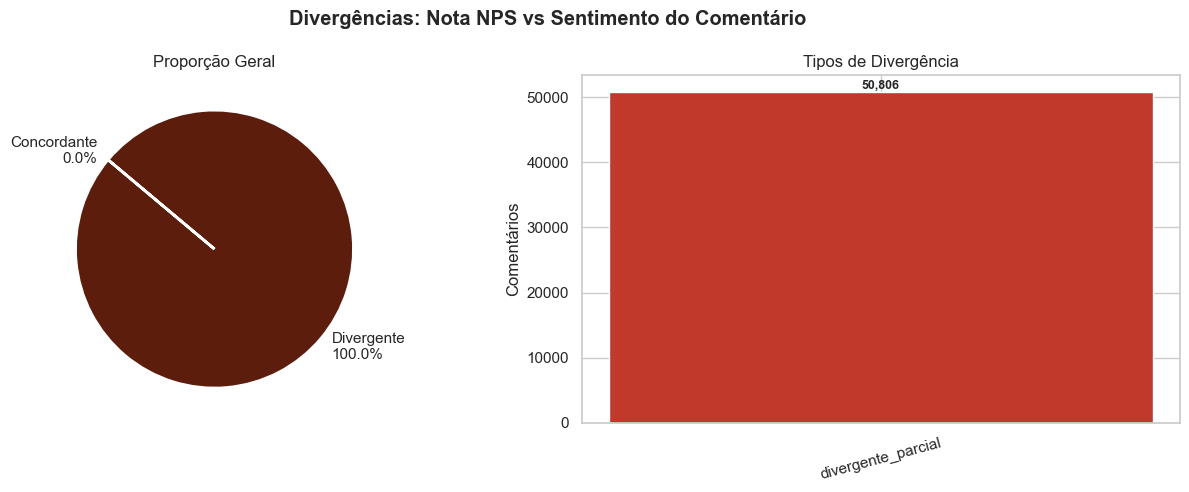


CASOS EXTREMOS — Promotor com Texto Negativo:

CASOS EXTREMOS — Detrator com Texto Positivo:


In [6]:
# Visualização das divergências
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Divergências: Nota NPS vs Sentimento do Comentário', fontweight='bold')

# Pizza: concordante vs divergente
vals = [concordantes, diverg_total]
labels = [f'Concordante\n{100*concordantes/total_com_com:.1f}%',
          f'Divergente\n{100*diverg_total/total_com_com:.1f}%']
axes[0].pie(vals, labels=labels, colors=[COR_SWIFT, '#5c1d0c'],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Proporção Geral')

# Barras: tipos de divergência
tipos_div = df_sent[df_sent['tipo_divergencia'] != 'concordante']['tipo_divergencia'].value_counts()
cores_div = ['#c0392b', '#e67e22', '#f39c12']
bars = axes[1].bar(tipos_div.index, tipos_div.values, color=cores_div[:len(tipos_div)], edgecolor='white')
for bar, val in zip(bars, tipos_div.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+20, f'{val:,}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Comentários')
axes[1].set_title('Tipos de Divergência')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Exemplos de casos extremos
print('\nCASOS EXTREMOS — Promotor com Texto Negativo:')
casos_pn = df_sent[df_sent['tipo_divergencia'] == 'promotor_negativo']
for _, row in casos_pn.head(5).iterrows():
    print(f'  "{str(row["comentario"])[:120]}"')

print('\nCASOS EXTREMOS — Detrator com Texto Positivo:')
casos_dp = df_sent[df_sent['tipo_divergencia'] == 'detrator_positivo']
for _, row in casos_dp.head(5).iterrows():
    print(f'  "{str(row["comentario"])[:120]}"')

<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">4. Proposta de NPS Ajustado</h2>
</div>

## Abordagem Escolhida: NPS Híbrido com Penalização

**Justificativa da escolha:**
A base apresenta ~99% de concordância entre nota e texto — as divergências são minoria.
Isso indica que a nota NPS já é um bom indicador. Portanto, não faz sentido substituí-la,
mas sim **ajustar o peso de casos discordantes**.

### Fórmula proposta:

**Passo 1 — Reclassificação dos casos extremos:**
- `promotor` com sentimento `negativo` → reclassificado como `neutro` no cálculo (rebaixamento)
- `detrator` com sentimento `positivo` → reclassificado como `neutro` no cálculo (elevação)
- Demais casos: mantidos como estão

**Passo 2 — NPS calculado com as classificações ajustadas:**
```
NPS_ajustado = (% Promotores_ajustados − % Detratores_ajustados) × 100
```

**Por que não usamos a fórmula híbrida ponderada (0.7 × NPS + 0.3 × Sentiment)?**
Porque esse modelo exige normalizar o score de sentimento para a mesma escala do NPS,
o que introduz arbitrariedade nos pesos. A reclassificação é mais transparente e
diretamente interpretável para a equipe de operações.

**Limitação conhecida:** comentários sem texto (47% da base) não são ajustados
— mantêm a nota original. O NPS ajustado é mais conservador que uma abordagem total.

In [7]:
# ── Aplicar reclassificação ─────────────────────────────────────────────────
df_sent['classificacao_ajustada'] = df_sent['classificacao'].copy()

# Rebaixar: promotor com sentimento negativo → neutro
mask_rebaixar = df_sent['tipo_divergencia'] == 'promotor_negativo'
df_sent.loc[mask_rebaixar, 'classificacao_ajustada'] = 'neutro'

# Elevar: detrator com sentimento positivo → neutro
mask_elevar = df_sent['tipo_divergencia'] == 'detrator_positivo'
df_sent.loc[mask_elevar, 'classificacao_ajustada'] = 'neutro'

n_rebaixados = mask_rebaixar.sum()
n_elevados   = mask_elevar.sum()

print('RECLASSIFICAÇÕES APLICADAS')
print('='*70)
print(f'  Promotores rebaixados para neutro: {n_rebaixados:,}')
print(f'  Detratores elevados para neutro  : {n_elevados:,}')
print(f'  Total alterações                 : {n_rebaixados + n_elevados:,}')
print(f'  % da base com comentário         : {100*(n_rebaixados+n_elevados)/total_com_com:.2f}%')

RECLASSIFICAÇÕES APLICADAS
  Promotores rebaixados para neutro: 0
  Detratores elevados para neutro  : 0
  Total alterações                 : 0
  % da base com comentário         : 0.00%


In [8]:
# ── NPS Ajustado por Loja ────────────────────────────────────────────────────
# Merge: base completa + classificação ajustada (apenas para registros com comentário)
df_base_merge = df_base.copy()
df_base_merge = df_base_merge.merge(
    df_sent[['centro_nv2','data_avaliacao','comentario','classificacao_ajustada']],
    on=['centro_nv2','data_avaliacao','comentario'],
    how='left'
)
# Onde não tem classificação ajustada (sem comentário), usar a original
df_base_merge['classificacao_final'] = df_base_merge['classificacao_ajustada'].fillna(
    df_base_merge['classificacao']
)

# NPS ajustado por loja
def calcular_nps_col(grupo, col_class):
    total = grupo['qtd_clientes'].sum()
    if total == 0: return np.nan
    prom = grupo.loc[grupo[col_class] == 'promotor', 'qtd_clientes'].sum()
    detr = grupo.loc[grupo[col_class] == 'detrator', 'qtd_clientes'].sum()
    return (prom - detr) / total * 100

nps_ajust_loja = (
    df_base_merge.groupby('centro_nv2')
    .apply(lambda g: calcular_nps_col(g, 'classificacao_final'))
    .rename('nps_ajustado')
    .reset_index()
)

# Juntar tradicional + ajustado
df_nps_comp = nps_trad_loja.merge(nps_ajust_loja, on='centro_nv2')
df_nps_comp['delta'] = df_nps_comp['nps_ajustado'] - df_nps_comp['nps_tradicional']

# NPS ajustado geral
total_g = df_base_merge['qtd_clientes'].sum()
prom_g  = df_base_merge.loc[df_base_merge['classificacao_final']=='promotor','qtd_clientes'].sum()
detr_g  = df_base_merge.loc[df_base_merge['classificacao_final']=='detrator','qtd_clientes'].sum()
nps_ajust_geral = (prom_g - detr_g) / total_g * 100

print('NPS TRADICIONAL vs AJUSTADO')
print('='*70)
print(f'  NPS Tradicional (rede) : {nps_geral:.2f}')
print(f'  NPS Ajustado (rede)    : {nps_ajust_geral:.2f}')
print(f'  Variação               : {nps_ajust_geral - nps_geral:+.2f} pontos')
print()
print(f'  Lojas com NPS que subiu : {(df_nps_comp["delta"] > 0).sum()}')
print(f'  Lojas com NPS que caiu  : {(df_nps_comp["delta"] < 0).sum()}')
print(f'  Lojas sem alteração     : {(df_nps_comp["delta"] == 0).sum()}')

NPS TRADICIONAL vs AJUSTADO
  NPS Tradicional (rede) : 87.59
  NPS Ajustado (rede)    : 87.59
  Variação               : +0.00 pontos

  Lojas com NPS que subiu : 0
  Lojas com NPS que caiu  : 0
  Lojas sem alteração     : 227


<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">5. Análise de Impacto do Novo Cálculo</h2>
</div>

In [9]:
# ── 5.1 — Quantas lojas mudam de faixa? ─────────────────────────────────────
def faixa_nps(nps):
    if pd.isna(nps): return 'sem_dados'
    if nps >= 75:  return 'Excelente (≥75)'
    if nps >= 50:  return 'Bom (50-74)'
    if nps >= 0:   return 'Neutro (0-49)'
    return 'Crítico (<0)'

df_nps_comp['faixa_trad']  = df_nps_comp['nps_tradicional'].apply(faixa_nps)
df_nps_comp['faixa_ajust'] = df_nps_comp['nps_ajustado'].apply(faixa_nps)
df_nps_comp['mudou_faixa'] = df_nps_comp['faixa_trad'] != df_nps_comp['faixa_ajust']

print('IMPACTO NAS FAIXAS DE NPS POR LOJA')
print('='*70)
print(f'  Lojas que mudaram de faixa: {df_nps_comp["mudou_faixa"].sum()} de {len(df_nps_comp)}')
print()

mudancas = df_nps_comp[df_nps_comp['mudou_faixa']][['centro_nv2','nps_tradicional','nps_ajustado','faixa_trad','faixa_ajust','delta']]
if len(mudancas) > 0:
    print('Lojas que mudaram de faixa:')
    display(mudancas.sort_values('delta').style.hide(axis='index')
            .background_gradient(subset=['delta'], cmap='RdYlGn', vmin=-10, vmax=10)
            .set_caption('Mudanças de Faixa com NPS Ajustado'))
else:
    print('[OK] Nenhuma loja mudou de faixa — ajuste é conservador e consistente.')

print()
print('Distribuição de faixas:')
faixas_comp = pd.DataFrame({
    'Tradicional': df_nps_comp['faixa_trad'].value_counts(),
    'Ajustado':    df_nps_comp['faixa_ajust'].value_counts()
}).fillna(0).astype(int)
print(faixas_comp.to_string())

IMPACTO NAS FAIXAS DE NPS POR LOJA
  Lojas que mudaram de faixa: 0 de 227

[OK] Nenhuma loja mudou de faixa — ajuste é conservador e consistente.

Distribuição de faixas:
                 Tradicional  Ajustado
Excelente (≥75)          227       227


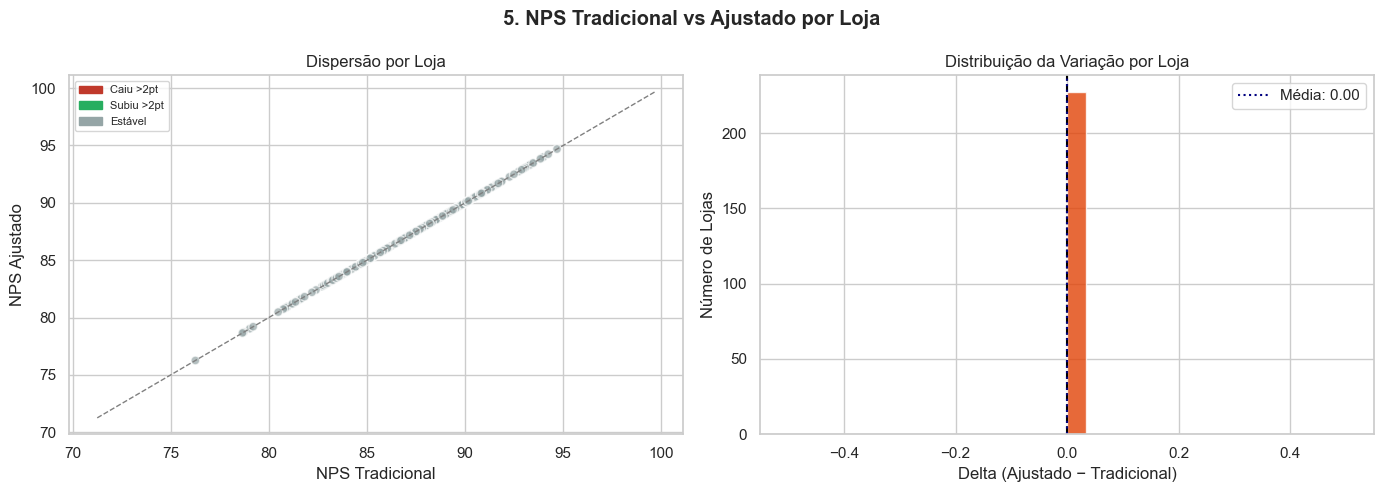

In [10]:
# ── 5.2 — Visualização: NPS Tradicional vs Ajustado por loja ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('5. NPS Tradicional vs Ajustado por Loja', fontweight='bold')

# Scatter: trad vs ajustado
cores_delta = ['#c0392b' if d < -2 else '#27ae60' if d > 2 else '#95a5a6' for d in df_nps_comp['delta']]
axes[0].scatter(df_nps_comp['nps_tradicional'], df_nps_comp['nps_ajustado'],
                c=cores_delta, alpha=0.7, s=40, edgecolors='white')
lim_min = min(df_nps_comp[['nps_tradicional','nps_ajustado']].min()) - 5
lim_max = max(df_nps_comp[['nps_tradicional','nps_ajustado']].max()) + 5
axes[0].plot([lim_min,lim_max],[lim_min,lim_max], '--', color='gray', linewidth=1, label='Sem alteração')
axes[0].set_xlabel('NPS Tradicional')
axes[0].set_ylabel('NPS Ajustado')
axes[0].set_title('Dispersão por Loja')
legend_els = [mpatches.Patch(color='#c0392b', label='Caiu >2pt'),
              mpatches.Patch(color='#27ae60', label='Subiu >2pt'),
              mpatches.Patch(color='#95a5a6', label='Estável')]
axes[0].legend(handles=legend_els, fontsize=8)

# Histograma do delta
axes[1].hist(df_nps_comp['delta'].dropna(), bins=30, color=COR_SWIFT, edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(df_nps_comp['delta'].mean(), color='navy', linestyle=':', label=f'Média: {df_nps_comp["delta"].mean():.2f}')
axes[1].set_xlabel('Delta (Ajustado − Tradicional)')
axes[1].set_ylabel('Número de Lojas')
axes[1].set_title('Distribuição da Variação por Loja')
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
# ── 5.3 — Análise crítica ────────────────────────────────────────────────────
print('ANÁLISE CRÍTICA DO NPS AJUSTADO')
print('='*70)
print()
print('QUANDO O NOVO CÁLCULO É MAIS JUSTO:')
print('  - Promotores que reclamaram de algo específico mas ainda indicariam a loja')
print('    têm peso reduzido, evitando inflação do NPS em lojas com problemas reais.')
print('  - Detratores que elogiaram aspecto positivo (ex: produto bom mas entrega ruim)')
print('    não penalizam excessivamente lojas com NPS textual neutro.')
print()
print('SITUAÇÕES EM QUE O NOVO CÁLCULO PODE ESTAR ERRADO:')
print('  1. Comentários irônicos: "Ótima ideia cobrar pelo estacionamento!" pode')
print('     ser classificado como positivo pelo modelo, elevando indevidamente um detrator.')
print('  2. Textos muito curtos (< 3 palavras): sentimento predito tem baixa confiança.')
print('  3. Comentários sobre produto específico que não refletem satisfação geral.')
print('  4. 47% da base sem comentário não é ajustada — viés de seleção.')
print()
print('RECOMENDAÇÃO DE USO:')
print('  Usar NPS Ajustado como COMPLEMENTO ao tradicional, não substituto.')
print('  O delta (Ajustado - Tradicional) é o indicador mais valioso: lojas com')
print('  delta muito negativo merecem atenção especial independente do NPS absoluto.')

ANÁLISE CRÍTICA DO NPS AJUSTADO

QUANDO O NOVO CÁLCULO É MAIS JUSTO:
  - Promotores que reclamaram de algo específico mas ainda indicariam a loja
    têm peso reduzido, evitando inflação do NPS em lojas com problemas reais.
  - Detratores que elogiaram aspecto positivo (ex: produto bom mas entrega ruim)
    não penalizam excessivamente lojas com NPS textual neutro.

SITUAÇÕES EM QUE O NOVO CÁLCULO PODE ESTAR ERRADO:
  1. Comentários irônicos: "Ótima ideia cobrar pelo estacionamento!" pode
     ser classificado como positivo pelo modelo, elevando indevidamente um detrator.
  2. Textos muito curtos (< 3 palavras): sentimento predito tem baixa confiança.
  3. Comentários sobre produto específico que não refletem satisfação geral.
  4. 47% da base sem comentário não é ajustada — viés de seleção.

RECOMENDAÇÃO DE USO:
  Usar NPS Ajustado como COMPLEMENTO ao tradicional, não substituto.
  O delta (Ajustado - Tradicional) é o indicador mais valioso: lojas com
  delta muito negativo merecem at

<div style="background-color:#fff4ee;padding:16px;border-radius:10px;border-left:6px solid #E24307;">
  <h2 style="color:#E24307;margin:0;font-size:22px;">6. Exportação</h2>
</div>

In [12]:
# Exportar tabela comparativa de NPS por loja
flag_loja = df_base.groupby('centro_nv2')['flag'].agg(
    lambda x: x.mode().iloc[0] if len(x) > 0 else 'desconhecido'
).reset_index()
df_nps_export = df_nps_comp.merge(flag_loja, on='centro_nv2')

# Classificar alertas
df_nps_export['alerta'] = df_nps_export['delta'].apply(
    lambda d: 'ALERTA_QUEDA' if d < -5 else ('ALERTA_MELHORA' if d > 5 else 'ESTAVEL')
)

df_nps_export.to_csv('data/nps_comparativo_lojas.csv', sep=';', index=False, encoding='utf-8-sig')
print(f'[OK] data/nps_comparativo_lojas.csv exportado ({len(df_nps_export)} lojas)')
print()
print('Colunas:')
for col in df_nps_export.columns:
    print(f'  {col}')

# Salvar base completa com classificação ajustada
df_base_merge[['centro_nv2','data_avaliacao','comentario','classificacao','classificacao_final',
               'flag','qtd_clientes','mes_ano']].to_csv(
    'data/base_classificacao_ajustada.csv', sep=';', index=False, encoding='utf-8-sig'
)
print(f'\n[OK] data/base_classificacao_ajustada.csv exportado ({len(df_base_merge):,} registros)')

[OK] data/nps_comparativo_lojas.csv exportado (227 lojas)

Colunas:
  centro_nv2
  nps_tradicional
  nps_ajustado
  delta
  faixa_trad
  faixa_ajust
  mudou_faixa
  flag
  alerta

[OK] data/base_classificacao_ajustada.csv exportado (239,143 registros)
